# NovaMart E-Commerce Analytics

**Business context.** NovaMart is a mid-size online retailer selling across six categories (Electronics, Home & Kitchen, Apparel, Beauty, Sports & Outdoors, Books). Leadership wants to understand what's driving revenue, which customers are worth retaining, and where the biggest growth and profitability levers are — ahead of planning next year's marketing budget.

**Guiding questions**
1. How is revenue trending, and how seasonal is the business?
2. Which products and categories actually drive the business?
3. Who are our best customers, and who are we losing? (RFM segmentation)
4. How well do we retain customers after their first purchase? (cohort analysis)
5. Which acquisition channels bring in the highest-value customers?

**Approach.** Data lives in a normalized SQLite database (`customers`, `products`, `orders`, `order_items`). The heavier aggregate queries — RFM scoring, cohort construction, Pareto/running totals — are written in SQL using CTEs and window functions (see `sql/analysis_queries.sql`); this notebook loads the cleaned data with `pandas`, reproduces those same metrics in Python, and visualizes the results.


## 1. Setup & data load

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
PALETTE = ["#2563eb", "#f97316", "#16a34a", "#dc2626", "#7c3aed", "#0891b2"]
plt.rcParams["figure.dpi"] = 150

conn = sqlite3.connect("../data/novamart.db")
customers = pd.read_sql("SELECT * FROM customers", conn, parse_dates=["signup_date"])
products  = pd.read_sql("SELECT * FROM products", conn)
orders    = pd.read_sql("SELECT * FROM orders", conn, parse_dates=["order_date"])
items     = pd.read_sql("SELECT * FROM order_items", conn)

print(customers.shape, products.shape, orders.shape, items.shape)

(800, 5) (60, 5) (6071, 4) (15138, 5)


## 2. Data validation

Before trusting any number, check for the usual data-quality issues: nulls, duplicate keys, and order statuses that shouldn't be counted as revenue (`cancelled` / `refunded`).

In [2]:
print("Nulls per table:")
for name, df in [("customers", customers), ("products", products), ("orders", orders), ("items", items)]:
    print(f"  {name}: {df.isna().sum().sum()}")
print("Duplicate order_ids:", orders.order_id.duplicated().sum())
print()
print(orders.status.value_counts())

Nulls per table:
  customers: 0
  products: 0
  orders: 0
  items: 0
Duplicate order_ids: 0

status
completed    5703
refunded      187
cancelled     181
Name: count, dtype: int64


**~6% of orders are cancelled or refunded** and are excluded from every revenue figure below — a small but easy-to-miss source of overstated revenue if you don't filter on `status`.

In [3]:
completed = orders[orders.status == "completed"]
line = items.merge(completed[["order_id", "order_date", "customer_id"]], on="order_id")
line = line.merge(products[["product_id", "product_name", "category", "unit_cost"]], on="product_id")
line["revenue"] = line.quantity * line.unit_price
line["profit"]  = line.quantity * (line.unit_price - line.unit_cost)

print(f"Clean, revenue-bearing line items: {len(line):,}")
print(f"Total net revenue (2023-2024):     ${line.revenue.sum():,.2f}")

Clean, revenue-bearing line items: 14,208
Total net revenue (2023-2024):     $2,218,406.43


## 3. Revenue trend

Equivalent to SQL query **#1** in `sql/analysis_queries.sql`.

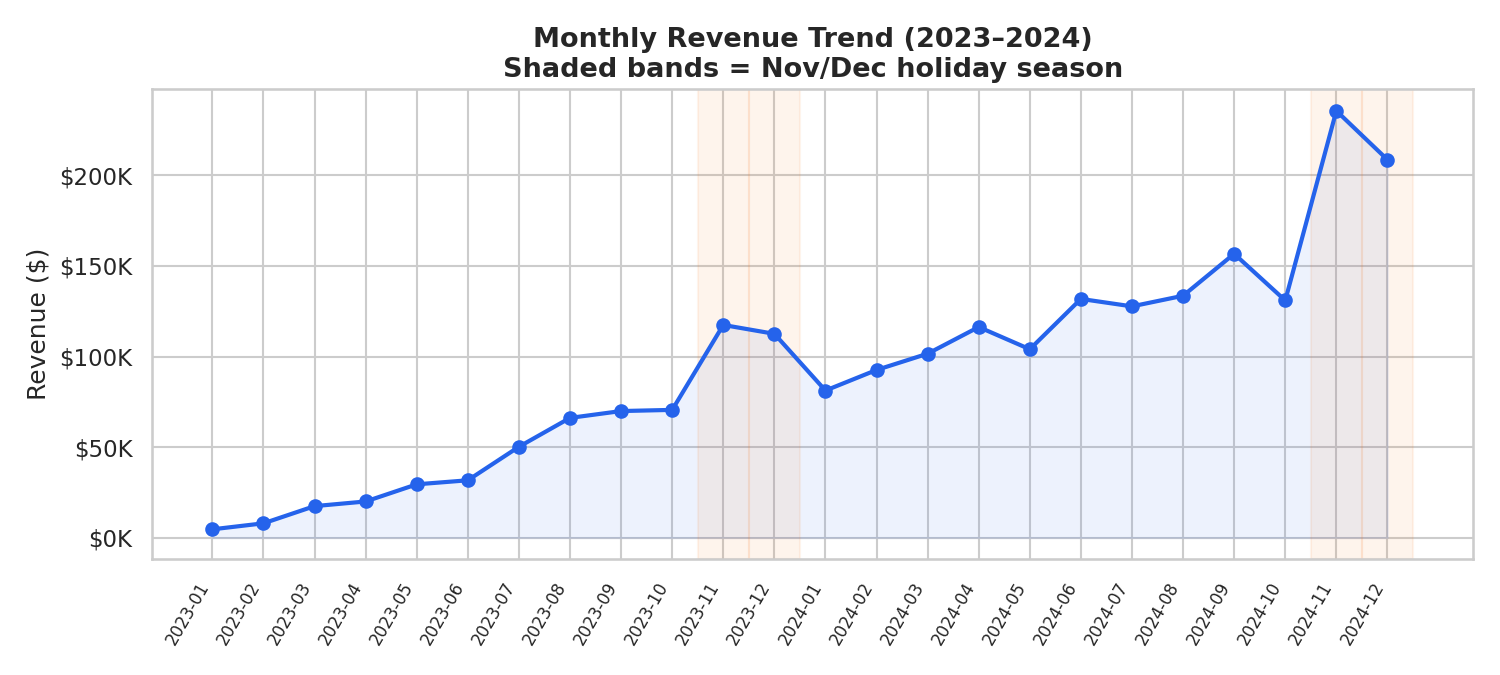

In [4]:
monthly = (line.assign(month=line.order_date.dt.to_period("M").astype(str))
               .groupby("month").agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"))
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly.month, monthly.revenue, marker="o", color=PALETTE[0], linewidth=2)
ax.fill_between(range(len(monthly)), monthly.revenue, color=PALETTE[0], alpha=0.08)
for i, m in enumerate(monthly.month):
    if m.endswith(("-11", "-12")):
        ax.axvspan(i - 0.5, i + 0.5, color=PALETTE[1], alpha=0.08)
ax.set_title("Monthly Revenue Trend (2023-2024)\nShaded bands = Nov/Dec holiday season")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

**Takeaway:** revenue grew roughly 4x from Jan 2023 to Dec 2024, with a clear, repeatable spike every November-December — strong evidence the business should plan inventory and marketing spend around a holiday peak rather than treating growth as flat.

## 4. Product & category performance

Equivalent to SQL queries **#2** and **#3**.

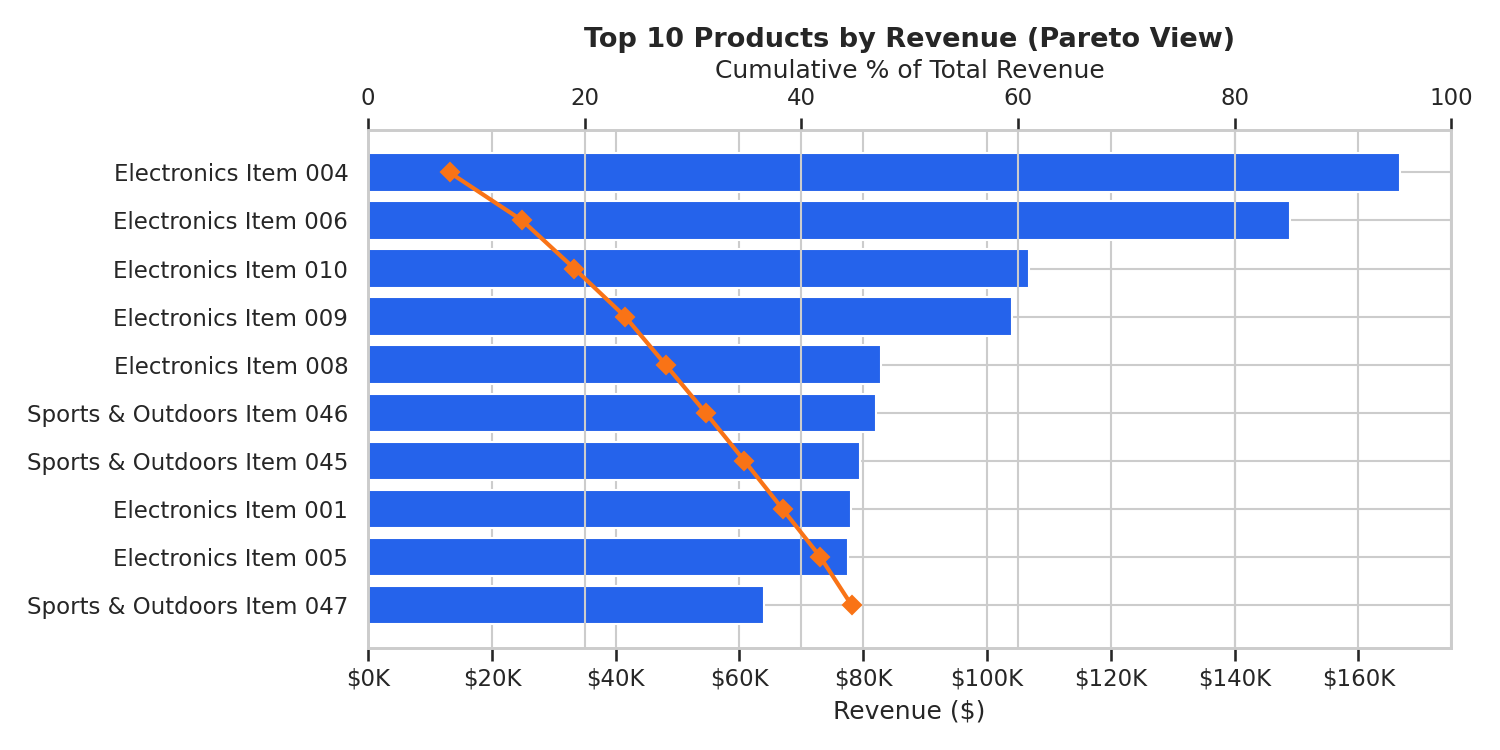

In [5]:
prod_rev = (line.groupby(["product_name", "category"]).revenue.sum()
                .reset_index().sort_values("revenue", ascending=False))
top10 = prod_rev.head(10).copy()
top10["cum_pct"] = 100 * top10.revenue.cumsum() / prod_rev.revenue.sum()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.barh(top10.product_name[::-1], top10.revenue[::-1], color=PALETTE[0])
ax1.set_xlabel("Revenue ($)"); ax1.set_title("Top 10 Products by Revenue (Pareto View)")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax2 = ax1.twiny()
ax2.plot(top10.cum_pct[::-1], top10.product_name[::-1], color=PALETTE[1], marker="D", linewidth=2)
ax2.set_xlabel("Cumulative % of Total Revenue"); ax2.set_xlim(0, 100)
plt.tight_layout()
plt.show()

**Takeaway:** the top 10 SKUs (out of 60) already account for ~45% of total revenue, and Electronics alone makes up 40% of category revenue — a classic Pareto pattern. Stockouts on these specific items would disproportionately hurt the business.

## 5. RFM customer segmentation

Recency, Frequency and Monetary value, each split into quartiles, combined into five actionable segments. Equivalent to SQL query **#4**.

In [6]:
snapshot = pd.Timestamp("2024-12-31")
rfm = line.groupby("customer_id").agg(
    last_order=("order_date", "max"),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum"),
).reset_index()
rfm["recency_days"] = (snapshot - rfm.last_order).dt.days

rfm["r_score"] = pd.qcut(rfm.recency_days.rank(method="first"), 4, labels=[4,3,2,1]).astype(int)
rfm["f_score"] = pd.qcut(rfm.frequency.rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["m_score"] = pd.qcut(rfm.monetary.rank(method="first"), 4, labels=[1,2,3,4]).astype(int)

def segment(row):
    if row.r_score >= 3 and row.f_score >= 3 and row.m_score >= 3: return "Champions"
    if row.r_score >= 3 and row.f_score <= 2: return "New / Promising"
    if row.r_score <= 2 and row.f_score >= 3 and row.m_score >= 3: return "At Risk (high value)"
    if row.r_score <= 2 and row.f_score <= 2: return "Lost / Dormant"
    return "Regular"

rfm["segment"] = rfm.apply(segment, axis=1)
seg = (rfm.groupby("segment").agg(customers=("customer_id","count"), avg_monetary=("monetary","mean"))
          .reset_index().sort_values("avg_monetary", ascending=False))
seg

               segment  customers  avg_monetary0            Champions        202   5655.2243561 At Risk (high value)        103   4755.5993202              Regular         46   2013.0084783      New / Promising        121   1666.7615704       Lost / Dormant        231   1263.843463

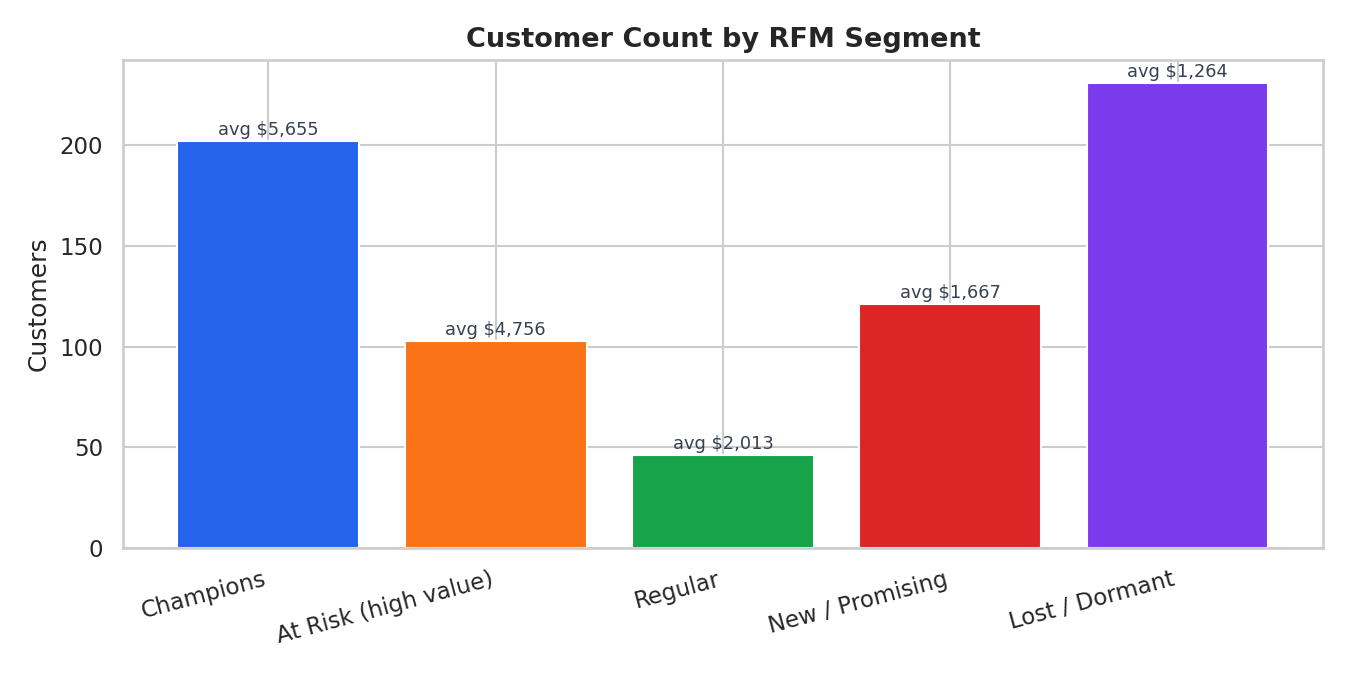

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(seg.segment, seg.customers, color=PALETTE[:len(seg)])
ax.set_title("Customer Count by RFM Segment"); ax.set_ylabel("Customers")
for b, v in zip(bars, seg.avg_monetary):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, f"avg \${v:,.0f}", ha="center", fontsize=8.5)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**Takeaway:** 231 customers (29%) are `Lost / Dormant`, but 103 `At Risk (high value)` customers still carry an average lifetime value of ~$4,755 — that's the group a win-back email campaign should target first, since they're worth far more to recover than the dormant group.

## 6. Cohort retention

For each monthly signup cohort, what share of customers were still active N months later? Equivalent to SQL query **#5**.

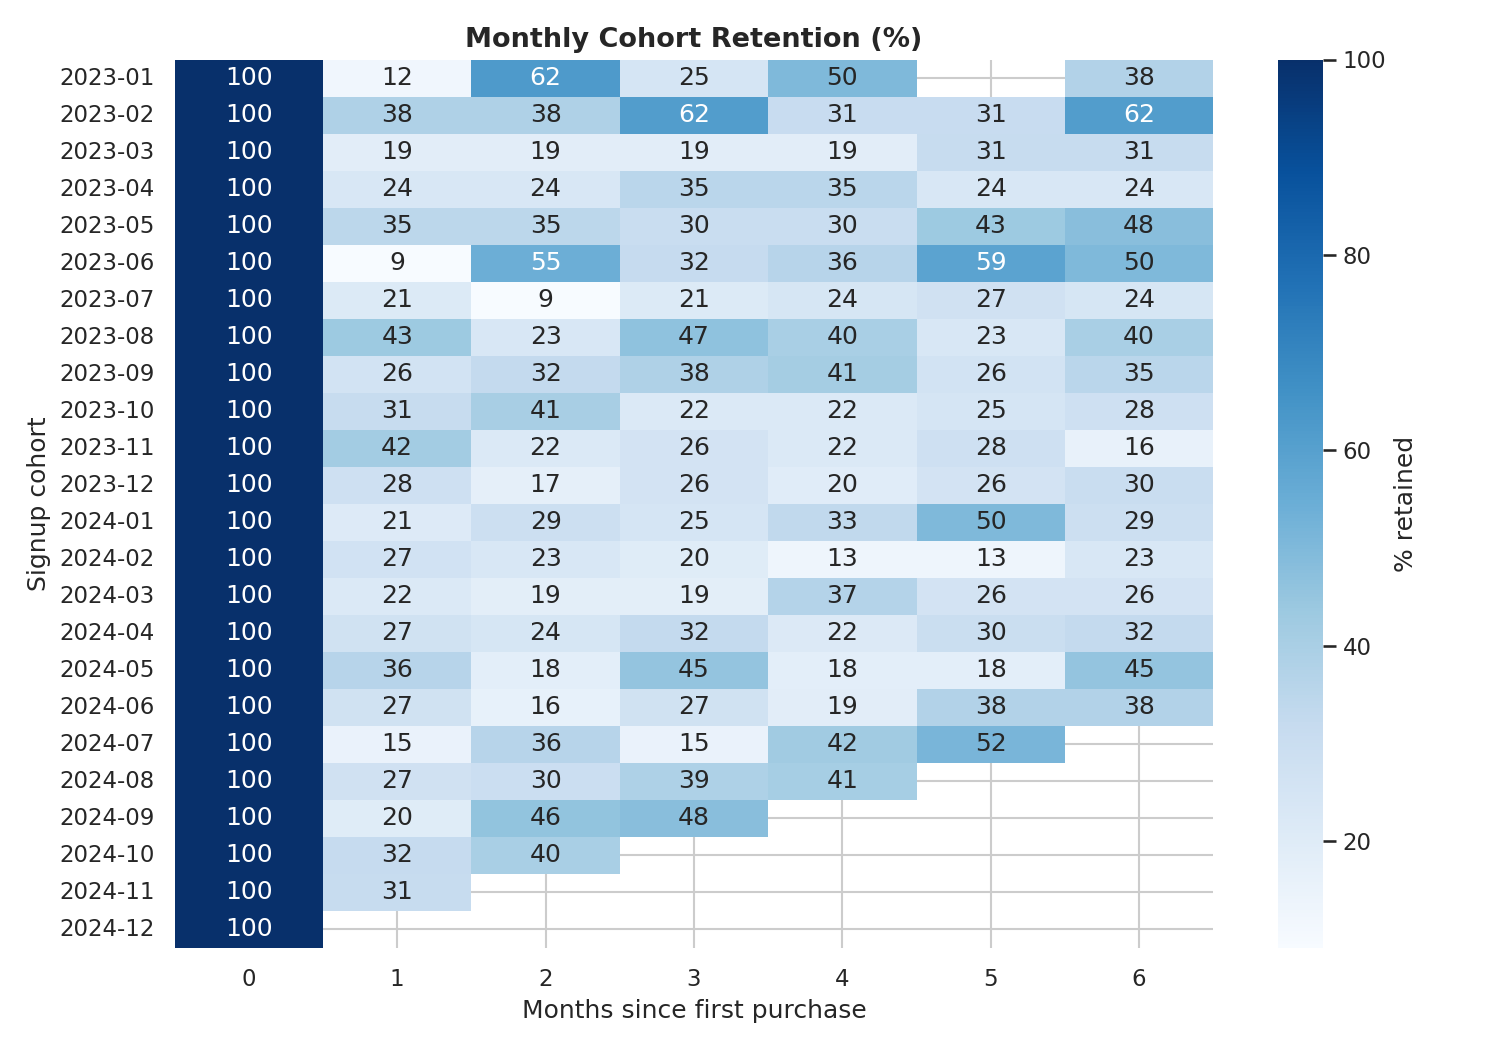

In [8]:
first_order = line.groupby("customer_id").order_date.min().dt.to_period("M")
line["cohort"] = line.customer_id.map(first_order)
line["order_month"] = line.order_date.dt.to_period("M")
line["month_number"] = (line.order_month - line.cohort).apply(lambda x: x.n)

cohort_counts = line.groupby(["cohort","month_number"]).customer_id.nunique().reset_index()
pivot = cohort_counts.pivot(index="cohort", columns="month_number", values="customer_id")
retention = pivot.divide(pivot[0], axis=0) * 100
retention = retention.iloc[:, :7]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% retained"}, ax=ax)
ax.set_title("Monthly Cohort Retention (%)")
ax.set_xlabel("Months since first purchase"); ax.set_ylabel("Signup cohort")
plt.tight_layout()
plt.show()

**Takeaway:** retention drops sharply after month 0 (as expected) but stabilizes in the 20-40% range rather than decaying to zero — meaning customers who make it past month 1 tend to become recurring buyers. That first-month drop-off is the highest-leverage point for a retention campaign.

## 7. Acquisition channel performance

Equivalent to SQL query **#6**.

In [9]:
chan = line.merge(customers[["customer_id","acquisition_channel"]], on="customer_id")
chan_summary = (chan.groupby("acquisition_channel")
    .agg(revenue=("revenue","sum"), orders=("order_id","nunique"), customers=("customer_id","nunique"))
    .reset_index())
chan_summary["aov"] = chan_summary.revenue / chan_summary.orders
chan_summary["orders_per_customer"] = chan_summary.orders / chan_summary.customers
chan_summary.sort_values("revenue", ascending=False)

  acquisition_channel    revenue  orders  customers    aov  orders_per_customer0      Organic Search  808028.39    2028        224  398.44                 9.051            Paid Ads  609316.50    1563        203  389.84                 7.703               Email  289267.78     726         90  398.44                 8.074       Social Media  218907.26     609         79  359.45                 7.712            Referral  292886.50     777        107  376.95                 7.26

**Takeaway:** Organic Search and Email drive the highest AOV (~$398) and the most orders per customer — Email in particular punches above its weight given it brings in the fewest new customers, suggesting it's retaining existing buyers rather than acquiring new ones.

## 8. Key findings & recommendations

1. **Seasonality is real and repeatable.** Nov/Dec consistently outperforms — plan inventory and ad spend around it rather than a flat monthly budget.
2. **Revenue is concentrated.** The top 10 of 60 products drive ~45% of revenue, and Electronics alone is 40% of category revenue. Stock-out risk on these SKUs should be treated as a priority, not an afterthought.
3. **103 high-value customers are at risk.** They haven't ordered recently but have strong historical spend (avg. ~$4,755) — a targeted win-back campaign here has a clearer ROI than a blanket promotion to all 800 customers.
4. **Month-1 retention is the biggest drop-off.** Customers who survive past their first month settle into a stable 20-40% monthly repurchase rate — a post-first-purchase email/onboarding flow is the highest-leverage retention lever.
5. **Email outperforms its acquisition volume.** Lower customer count but comparable AOV and higher orders-per-customer than Paid Ads — worth a larger share of the retention (not just acquisition) budget.

## Tech stack

`SQL` (SQLite — CTEs, window functions, `NTILE`) · `Python` (`pandas`, `numpy`) · `Data visualization` (`matplotlib`, `seaborn`) · Jupyter Notebook

See `sql/analysis_queries.sql` for the SQL-only version of every metric in this notebook.
